In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler,LabelEncoder,LabelBinarizer

import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc,classification_report
from sklearn import svm
import matplotlib.pyplot as plt
from joblib import dump, load
import seaborn as sns

from sklearn.metrics import RocCurveDisplay
from data_preprossing import data_preprocessing


In [2]:
X_train, X_test, y_train, y_test  = data_preprocessing()
def plot_confusion_matrix(model, X, y):
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [3]:
svm_model = load('svm_model.joblib')
y_pred = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8484558118965136
Classification Report:
               precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90     10193
        >50K       0.77      0.56      0.65      3374

    accuracy                           0.85     13567
   macro avg       0.82      0.75      0.78     13567
weighted avg       0.84      0.85      0.84     13567



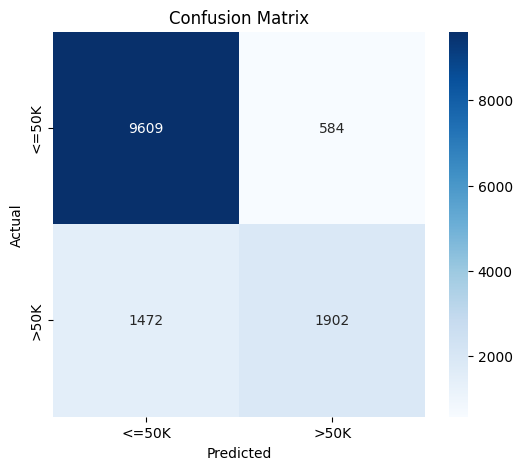

In [4]:
plot_confusion_matrix(svm_model, X_test, y_test)

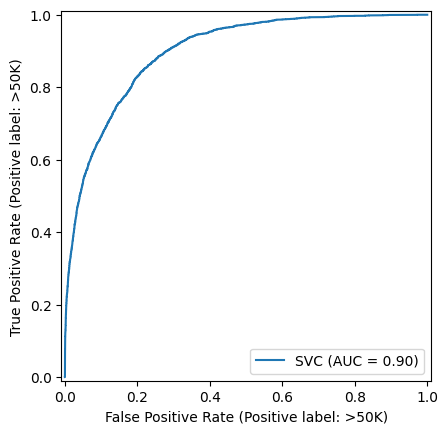

In [5]:
svc_disp = RocCurveDisplay.from_estimator(svm_model, X_test, y_test)
plt.show()